# E-commerce Customer Segmentation with RFM

This notebook presents the **final portfolio workflow** from the broader customer-segmentation project.

The original analysis explored several clustering strategies. The final model uses **Recency, Frequency and Monetary (RFM)** features with **K-Means (K=4)** because it offered the clearest balance of quantitative quality, stability and business interpretability.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

DATA = Path("../data/ecommerce_consumer_behavior.csv")
df = pd.read_csv(DATA)
df.shape

(1000, 28)

## RFM feature engineering

- **Recency:** days since purchase using `2024-12-31` as the reproducible observation date
- **Frequency:** recorded purchase frequency
- **Monetary:** cleaned numeric purchase amount

The three features are Min-Max scaled before clustering.

In [2]:
monetary = (
    df["Purchase_Amount"].astype(str)
      .str.replace("$", "", regex=False)
      .str.replace(",", "", regex=False)
      .str.strip()
      .astype(float)
)

dates = pd.to_datetime(df["Time_of_Purchase"], format="mixed")
rfm_raw = pd.DataFrame({
    "RECENCY": (pd.Timestamp("2024-12-31") - dates).dt.days.clip(lower=0),
    "FREQUENCY": df["Frequency_of_Purchase"].astype(float),
    "MONETARY": monetary,
})

rfm = pd.DataFrame(
    MinMaxScaler().fit_transform(rfm_raw),
    columns=rfm_raw.columns,
    index=rfm_raw.index,
)
rfm_raw.describe().round(2)

,RECENCY,FREQUENCY,MONETARY
count,1000.00,1000.00,1000.00
mean,184.73,6.94,275.06
std,100.69,3.15,131.53
min,1.00,2.00,50.71
25%,103.00,4.00,162.24
50%,184.00,7.00,276.16
75%,271.00,10.00,388.98
max,365.00,12.00,498.33


## Choosing K

In [3]:
rows = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels_k = model.fit_predict(rfm)
    rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(rfm, labels_k),
        "davies_bouldin": davies_bouldin_score(rfm, labels_k),
    })

k_table = pd.DataFrame(rows)
k_table.round(3)

,k,inertia,silhouette,davies_bouldin
0,2,187.362,0.265,1.510
1,3,146.870,0.262,1.243
2,4,115.910,0.289,1.128
3,5,98.809,0.282,1.081
4,6,84.884,0.285,1.020
5,7,74.104,0.282,1.027
6,8,65.220,0.282,1.025


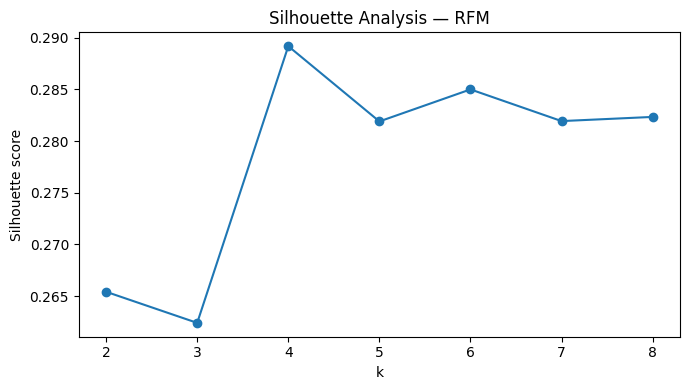

In [4]:
plt.figure(figsize=(7,4))
plt.plot(k_table["k"], k_table["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Analysis — RFM")
plt.tight_layout()
plt.show()

## Final K=4 segmentation

In [5]:
model = KMeans(n_clusters=4, random_state=42, n_init=50)
labels = model.fit_predict(rfm)

profile = rfm_raw.assign(cluster=labels).groupby("cluster").agg(
    customers=("RECENCY", "size"),
    recency_days=("RECENCY", "mean"),
    frequency=("FREQUENCY", "mean"),
    monetary=("MONETARY", "mean"),
).round(2)

profile

,customers,recency_days,frequency,monetary
cluster,,,,
0,261,156.26,9.08,406.58
1,264,213.48,9.66,160.71
2,226,278.26,4.39,328.50
3,249,99.19,4.14,209.95


In [6]:
sil = silhouette_score(rfm, labels)
dbi = davies_bouldin_score(rfm, labels)

labelings = [
    KMeans(n_clusters=4, random_state=s, n_init=20).fit_predict(rfm)
    for s in range(5)
]
aris = [
    adjusted_rand_score(labelings[i], labelings[j])
    for i in range(len(labelings))
    for j in range(i + 1, len(labelings))
]

pd.DataFrame([{"silhouette": sil,
               "davies_bouldin": dbi,
               "mean_pairwise_ari": np.mean(aris),
               "std_pairwise_ari": np.std(aris)}]).round(3)

,silhouette,davies_bouldin,mean_pairwise_ari,std_pairwise_ari
0,0.289,1.128,0.98,0.012


## Interpretation

The four deterministic cluster IDs are translated into business-friendly RFM profiles:

- **Cluster 0 — High-Value Repeat Customers:** high frequency and the highest spend.
- **Cluster 1 — Frequent Low-Spend Customers:** very frequent purchasing but low monetary value.
- **Cluster 2 — Lapsed High-Spend Customers:** older recency with meaningful historical spend.
- **Cluster 3 — Recent Occasional Customers:** recent activity but low purchase frequency.

Marketing actions in the README are recommendations derived from these profiles and were not experimentally tested.